In [ ]:
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
data = pd.read_csv('indicepanel.csv')
data.head()

,spy,spy_lag1,Price,sp500,nasdaq,dji,cac40,daxi,aord,hsi,nikkei
0,-1.529998,-1.570008,143.339996,-3.540039,-40.879883,2.43945,5.489746,-27.990235,-2.300293,515.349609,-464.320313
1,0.270004,-1.529998,141.809998,-29.940064,-56.930176,-245.40918,-111.689941,-102.709961,-27.500000,216.951171,-48.830078
2,-2.990006,0.270004,142.080002,1.640015,-7.179931,19.75000,44.509766,33.680176,-33.899902,-354.060547,99.370117
3,0.589997,-2.990006,139.089996,-25.459961,-63.119873,-230.69043,-17.109864,-5.270020,-12.900390,768.359375,234.450195
4,1.100006,0.589997,139.679993,16.530029,8.270019,142.90039,9.140137,-40.120117,-100.200196,-195.560547,-158.209961


In [ ]:
# Define split indices
train_start = -2000
train_end = -1000
test_start = train_end  # continuation from where training ended

# Split data
Train = data.iloc[train_start:train_end].copy()
Test = data.iloc[test_start:].copy()

In [ ]:
# Define regression formula
formula = 'spy ~ spy_lag1 + sp500 + nasdaq + dji + cac40 + aord + daxi + nikkei + hsi'

# Fit model on training data
model = smf.ols(formula=formula, data=Train).fit()

# Generate predictions
Train['PredictedY'] = model.predict(Train)
Test['PredictedY'] = model.predict(Test)

## **Profit of the Signal-based Strategy**

### **Train set Strategy Evaluation**

In [ ]:
# Generate trading signals: +1 for long, -1 for short
Train['Order'] = np.where(Train['PredictedY'] > 0, 1, -1)

# Calculate profit per trade
Train['Profit'] = Train['spy'] * Train['Order']

# Compute cumulative wealth
Train['Wealth'] = Train['Profit'].cumsum()

# Output total profit
total_profit = Train['Profit'].sum()
print(f"Total profit made in training set: {total_profit:.2f}")


Total profit made in training set: 214.34


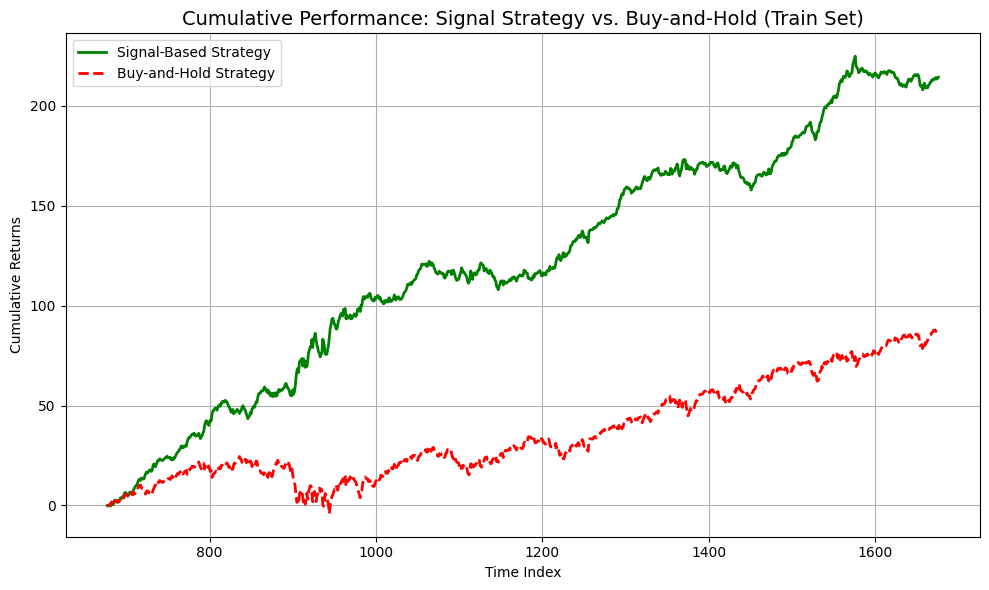

In [ ]:
# Plot cumulative performance of the signal-based strategy vs. buy-and-hold
plt.figure(figsize=(10, 6))
plt.title('Cumulative Performance: Signal Strategy vs. Buy-and-Hold (Train Set)', fontsize=14)
plt.plot(Train['Wealth'], label='Signal-Based Strategy', color='green', linewidth=2)
plt.plot(Train['spy'].cumsum(), label='Buy-and-Hold Strategy', color='red', linestyle='--', linewidth=2)
plt.xlabel('Time Index')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### **Test set strategy evaluation**

In [ ]:
# Generate trading signals based on predicted returns
Test['Order'] = np.where(Test['PredictedY'] > 0, 1, -1)

# Calculate profit based on signal direction
Test['Profit'] = Test['spy'] * Test['Order']

# Track cumulative profit over time
Test['Wealth'] = Test['Profit'].cumsum()

# Report total profit
total_test_profit = Test['Profit'].sum()
print(f"Total profit made in test set: {total_test_profit:.2f}")


Total profit made in test set: 241.03


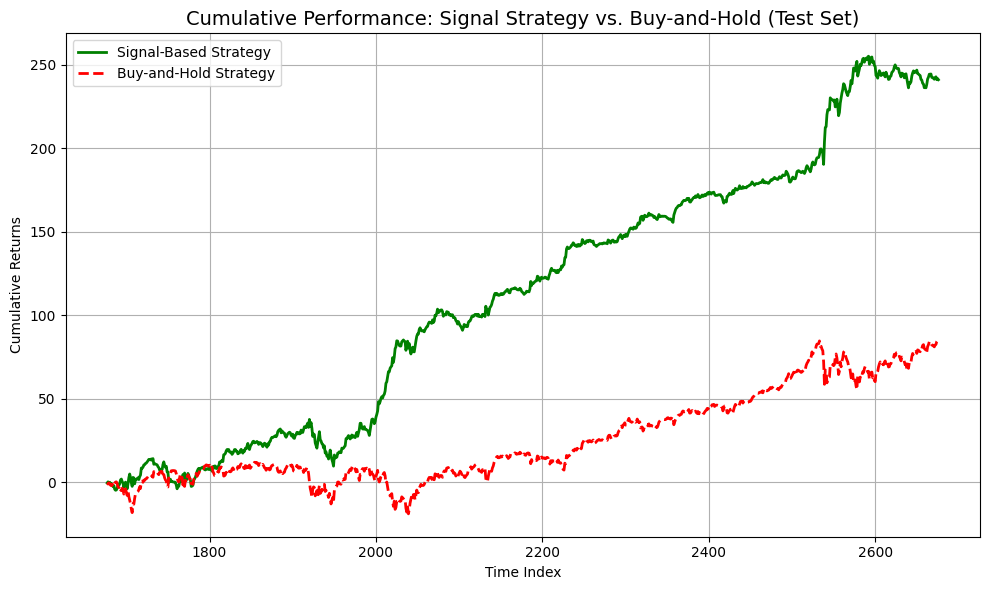

In [ ]:
# Plot cumulative performance of signal-based strategy vs. buy-and-hold on test data
plt.figure(figsize=(10, 6))
plt.title('Cumulative Performance: Signal Strategy vs. Buy-and-Hold (Test Set)', fontsize=14)
plt.plot(Test['Wealth'], label='Signal-Based Strategy', color='green', linewidth=2)
plt.plot(Test['spy'].cumsum(), label='Buy-and-Hold Strategy', color='red', linestyle='--', linewidth=2)
plt.xlabel('Time Index')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## **Evaluation of the Model using Practical Standards**
I will use two common practical standands - **Sharpe Ratio & Maximum Drawdown**, to evaluate the model performance.

In [ ]:
# Offset cumulative wealth by initial price to simulate absolute value over time
initial_price_train = Train.loc[Train.index[0], 'Price']
initial_price_test = Test.loc[Test.index[0], 'Price']

Train['Wealth'] += initial_price_train
Test['Wealth'] += initial_price_test

# Define function to compute Sharpe Ratio and Max Drawdown
def evaluate_performance(df, label='Dataset'):
    # Compute log returns
    df['Return'] = np.log(df['Wealth'] / df['Wealth'].shift(1))
    daily_returns = df['Return'].dropna()

    # Sharpe Ratio
    daily_sharpe = daily_returns.mean() / daily_returns.std(ddof=1)
    annual_sharpe = (252 ** 0.5) * daily_sharpe

    # Maximum Drawdown
    df['Peak'] = df['Wealth'].cummax()
    df['Drawdown'] = (df['Peak'] - df['Wealth']) / df['Peak']
    max_drawdown = df['Drawdown'].max()

    # Output metrics
    print(f"--- Performance Metrics: {label} ---")
    print(f"Daily Sharpe Ratio  : {daily_sharpe:.4f}")
    print(f"Annual Sharpe Ratio : {annual_sharpe:.4f}")
    print(f"Maximum Drawdown    : {max_drawdown:.2%}")
    print()


In [ ]:
# Evaluate on Train and Test sets
evaluate_performance(Train, label='Train')
evaluate_performance(Test, label='Test')

--- Performance Metrics: Train ---
Daily Sharpe Ratio  : 0.1797
Annual Sharpe Ratio : 2.8519
Maximum Drawdown    : 6.07%

--- Performance Metrics: Test ---
Daily Sharpe Ratio  : 0.1304
Annual Sharpe Ratio : 2.0693
Maximum Drawdown    : 11.72%



**Interpretaon Summary**

| Metric               | Train | Test            | Interpretation                               |
| -------------------- | ----- | --------------- | -------------------------------------------- |
| Sharpe (Annual)      | 2.85  | 2.07            | Excellent generalization; strong signal      |
| Max Drawdown         | 6.07% | 11.72%          | Controlled downside risk; still conservative |
| Volatility (Implied) | Lower | Slightly higher | Model adapts to new data but retains control |
